In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import numpy as np
import os
import matplotlib.pyplot as plt
#  set font size
plt.rcParams.update({'font.size': 16})
cwd = os.getcwd()
# parent directory
parent = os.path.dirname(cwd)
import sys
sys.path.append(parent)
from utils import data, utils

idb = 3
db = data.dbs[idb]

In [44]:
# data_dir = '../data/old-202403/processed data/'
root_dir = '/media/carsen/ssd1/github/SuperiorColliculus/data/version3/'
data_dir = f'/media/carsen/ssd1/github/SuperiorColliculus/data/version3/preprocessed/{db["mname"]}/{db["datexp"]}/'
filenames = os.listdir(data_dir)
print(filenames)

['rois.id.npy', 'calcium.timestamps.npy', 'sparse.map.npy', 'wheel.timestamps.npy', 'body.timestamps.npy', 'spout.licks.npy', 'rois.isZCorrected.npy', 'suite2p', 'natural.fileIndex.npy', 'naturalExp.intervals.npy', 'sparse.startTime.npy', 'natural.endTime.npy', 'planes.zTrace.npy', 'spout.timestamps.npy', 'natural.startTime.npy', 'suite2p(4)', 'sparse.endTime.npy', 'calcium.dff.npy', 'fullField.endTime.npy', 'fullFieldExp.intervals.npy', 'rois.xyz.npy', 'planes.zcorrelation.npy', 'fullField.startTime.npy', 'suite2p(4).zip', 'sparseExp.edges.npy', 'wheel.velocity.npy', 'rois.zProfiles.npy', 'eye.timestamps.npy', 'naturalExp.imgList.npy', 'sparseExp.intervals.npy', 'planes.delay.npy', 'fullField.stim.npy', 'rois.planes.npy']


In [45]:
for filename in filenames:
    if '.npy' not in filename:
        continue
    if filename == 'natural.fileNames.npy':
        dat = np.load(data_dir + filename)
        print(filename, dat.shape)
    elif filename == 'naturalExp.imgList.npy':
        print(filename, dat.shape)
    elif filename in ['imgs_cut.npy', 'natural.fileIndex.npy']:
        dat = np.load(data_dir + filename, allow_pickle=True)
        print(filename, dat.shape)
    else:
        dat = np.load(data_dir + filename, allow_pickle=True)
        print(filename, dat.shape, dat.min(), dat.max())

rois.id.npy (64,) 0 372
calcium.timestamps.npy (84989, 1) nan nan
sparse.map.npy (1739, 16, 18) 0.0 1.0
wheel.timestamps.npy (1516365, 1) -24.718 2856.005224746319
body.timestamps.npy (169866, 1) nan nan
spout.licks.npy (2856050, 1) nan nan
rois.isZCorrected.npy (64,) True True
natural.fileIndex.npy (6200, 1)
naturalExp.intervals.npy (2, 2) 360.178 2343.848
sparse.startTime.npy (1739, 1) 10.263 299.934
natural.endTime.npy (6200, 1) 360.27099999999996 2343.848
planes.zTrace.npy (1, 84989) 0 9
spout.timestamps.npy (2856050, 1) 0.0 2856.0460000000003
natural.startTime.npy (6200, 1) 360.178 2343.688
sparse.endTime.npy (1739, 1) 10.423 300.106
calcium.dff.npy (84989, 64) nan nan
fullField.endTime.npy (130, 1) 2370.101 2849.0679999999998
fullFieldExp.intervals.npy (1, 2) 2367.063 2849.0679999999998
rois.xyz.npy (64, 3) 0.0009495822929759257 352.265625
planes.zcorrelation.npy (1, 100, 84989) 0.0015500957 0.028523805
fullField.startTime.npy (130, 1) 2367.063 2846.043
sparseExp.edges.npy (6, 1)

In [46]:
img_list = np.load(os.path.join(data_dir, 'naturalExp.imgList.npy'), allow_pickle=True)
nat_img_list = img_list[0][0]['imgList'][:, 0]
txt_img_list = img_list[1][0]['imgList'][:, 0]
print(nat_img_list.shape, txt_img_list.shape)

(3000,) (32,)


In [47]:
txt_img_list

array(['E:\\Textures\\0.jpg', 'E:\\Textures\\1.jpg',
       'E:\\Textures\\2.jpg', 'E:\\Textures\\3.jpg',
       'E:\\Textures\\4.jpg', 'E:\\Textures\\5.jpg',
       'E:\\Textures\\6.jpg', 'E:\\Textures\\7.jpg',
       'E:\\Textures\\8.jpg', 'E:\\Textures\\9.jpg',
       'E:\\Textures\\10.jpg', 'E:\\Textures\\11.jpg',
       'E:\\Textures\\12.jpg', 'E:\\Textures\\13.jpg',
       'E:\\Textures\\14.jpg', 'E:\\Textures\\15.jpg',
       'E:\\Textures\\16.jpg', 'E:\\Textures\\17.jpg',
       'E:\\Textures\\18.jpg', 'E:\\Textures\\19.jpg',
       'E:\\Textures\\20.jpg', 'E:\\Textures\\21.jpg',
       'E:\\Textures\\22.jpg', 'E:\\Textures\\23.jpg',
       'E:\\Textures\\24.jpg', 'E:\\Textures\\25.jpg',
       'E:\\Textures\\26.jpg', 'E:\\Textures\\27.jpg',
       'E:\\Textures\\28.jpg', 'E:\\Textures\\29.jpg',
       'E:\\Textures\\30.jpg', 'E:\\Textures\\31.jpg'], dtype=object)

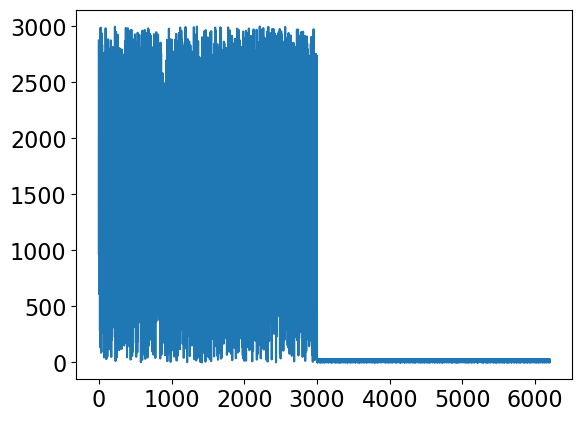

In [48]:
nat_file_indexes = np.load(os.path.join(data_dir, 'natural.fileIndex.npy'), allow_pickle=True)
plt.plot(nat_file_indexes.squeeze())
# first 3k images are natural, next 3k are Miguel's 32 textures

# load image data

In [49]:
file_idxes = np.load(os.path.join(data_dir, 'natural.fileIndex.npy'), allow_pickle=True)
print('file index:', file_idxes.shape, file_idxes.min(), file_idxes.max())

txt_indexes = np.arange(3000, len(file_idxes))
txt_file_idxes = file_idxes.squeeze()[txt_indexes] # the first 3000 images are natural images, the rest are oneshot textures

istim = txt_file_idxes.copy() # the file indexes are corresponding to the image names
print('istim:', istim.shape, istim.min(), istim.max())

# load the images
imgdir = os.path.join(root_dir, 'NImages')
images = []
unique_istim = np.unique(istim)
for i in range(unique_istim.shape[0]):
    img_name = f'{unique_istim[i]}.jpg'
    img_path = os.path.join(imgdir, img_name)
    # read image as a matrix
    img = plt.imread(img_path)
    images.append(img)
images = np.array(images)
print(images.shape)

file index: (6200, 1) 0 2999
istim: (3200,) 0 31
(32, 66, 77)


# preprocess the neural data

In [50]:
# record at 30 Hz
# 6 images per trial (3 natural + 3 grayscale)
trial_start_time = np.load(os.path.join(data_dir, 'natural.startTime.npy'))
print('trial start time:', trial_start_time.shape, trial_start_time.min(), trial_start_time.max())

trial_end_time = np.load(os.path.join(data_dir, 'natural.endTime.npy'))
print('trial end time:', trial_end_time.shape, trial_end_time.min(), trial_end_time.max())

timestamps = np.load(os.path.join(data_dir, 'calcium.timestamps.npy'))
timestamps = timestamps.squeeze()
print('timestamps:', timestamps.shape, timestamps.min(), timestamps.max())

dff = np.load(os.path.join(data_dir, 'calcium.dff.npy'))
print('dff:', dff.shape, dff.min(), dff.max())
# timestamps has NaN values, change them to -1
# timestamps[np.isnan(timestamps)] = -1

n_trials = trial_start_time.shape[0]    
assert trial_end_time.shape[0] == trial_start_time.shape[0]

trial start time: (6200, 1) 360.178 2343.688
trial end time: (6200, 1) 360.27099999999996 2343.848
timestamps: (84989,) nan nan
dff: (84989, 64) nan nan


In [51]:
# load the calcium data
# raw_spks = np.load(os.path.join(data_dir, 'suite2p', 'spks.npy'), allow_pickle=True)    
# icell = np.load(os.path.join(data_dir, 'suite2p', 'iscell.npy'))[:,0]
# raw_spks = raw_spks[icell>0.5]
raw_spks, ops, xpos, ypos, iplane = data.load_dataset(data_dir, deconv=1)
n_neurons, n_frames = raw_spks.shape
print(raw_spks.shape, raw_spks.min(), raw_spks.max())

# remove the frames where timestamps are NaN
nanframes = np.isnan(timestamps)
timestamps = timestamps[~nanframes]
raw_spks = raw_spks[:, ~nanframes]

# add the nan from dff to remove the values excluded based on z-correction
raw_spks[np.isnan(dff[~nanframes].T)] = np.nan
n_neurons, n_frames = raw_spks.shape
print(raw_spks.shape, raw_spks.min(), raw_spks.max())

total neurons 64
(64, 84989) 0.0 691.61816
(64, 84988) nan nan


Text(0.5, 1.0, 'neuron 1')

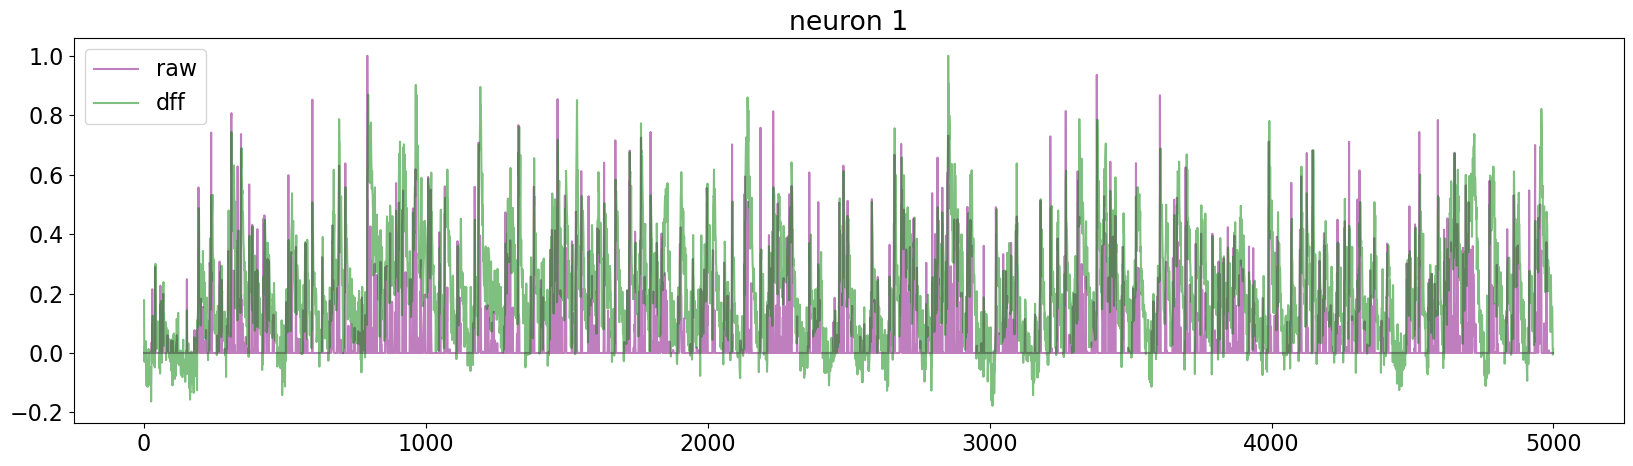

In [53]:
fig, ax = plt.subplots(1,1,figsize=(20, 5))
ineuron = 1
trange = np.arange(5000)
plt.plot(raw_spks[ineuron, trange]/raw_spks[ineuron, trange].max() , label='raw', color='purple', alpha=0.5)
plt.plot(dff[trange, ineuron]/dff[trange, ineuron].max() , label='dff', alpha=0.5, color='green')
plt.legend()
plt.title(f'neuron {ineuron}')

In [54]:
spks = np.zeros((n_neurons, n_trials))
frame_lag = 1
nframes_list = []
trial_flag = np.zeros(n_frames, dtype=bool)
trial_spks = []
trial_time = []
for i in range(n_trials):
    trial_start = trial_start_time[i]
    trial_end = trial_end_time[i]
    trial_start_iframe = np.where(timestamps >= trial_start)[0][0] + frame_lag
    trial_end_iframe = np.where(timestamps <= trial_end)[0][-1] + frame_lag
    if trial_end_iframe - trial_start_iframe < 1:
        trial_end_iframe = trial_start_iframe + 1
        print(f'Warning: trial {i} has less than 1 frame')
    spks[:, i] = np.nanmean(raw_spks[:, trial_start_iframe:trial_end_iframe], axis=1)
    # raw_spks[:, trial_start_iframe:trial_end_iframe].mean(axis=1)
    nframes_list.append(trial_end_iframe - trial_start_iframe)
    trial_flag[trial_start_iframe:trial_end_iframe] = True
    trial_spks.append(raw_spks[:, trial_start_iframe-3:trial_start_iframe+11])
    trial_time.append(trial_end)
print(spks.shape, spks.min(), spks.max())
nframes = np.array(nframes_list)
print(nframes.shape, nframes.min(), nframes.max())
spks = spks[:, txt_indexes]
print(spks.shape, spks.min(), spks.max())
trial_time = np.array(trial_time)
print(trial_time.shape, trial_time.min(), trial_time.max())

/tmp/ipykernel_1954880/513923072.py:15: RuntimeWarning: Mean of empty slice
  spks[:, i] = np.nanmean(raw_spks[:, trial_start_iframe:trial_end_iframe], axis=1)


(64, 6200) nan nan
(6200,) 2 5
(64, 3200) nan nan
(6200, 1) 360.27099999999996 2343.848


In [55]:
trial_spks = np.array(trial_spks)
print(trial_spks.shape)
trial_spks_all = trial_spks.copy()

(6200, 64, 14)


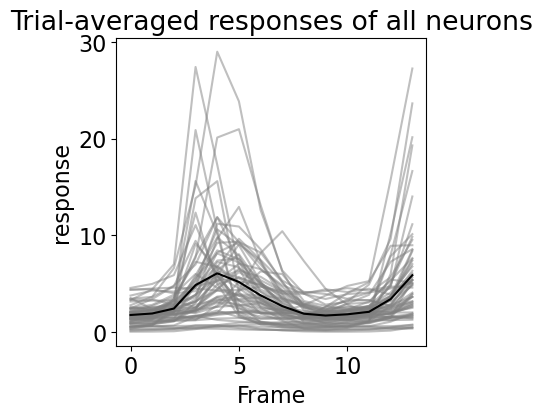

In [56]:
trial_spks = trial_spks_all[3000:]
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# plot all neurons
cmap = plt.get_cmap('bwr')
for i in range(n_neurons):
    trial_spk = np.nanmean(trial_spks[:, i, :], axis=0)
    # trial_spk = trial_spk - trial_spk.min()
    ax.plot(trial_spk, label=f'neuron {i}', color='gray', alpha=0.5)
# plot the mean
ax.plot(np.nanmean(trial_spks, axis=(0,1)), label='mean', color='black')
# ax.legend()
ax.set_xlabel('Frame')
ax.set_ylabel('response')
ax.set_title('Trial-averaged responses of all neurons')
plt.show()

# save data

In [57]:
print(istim.shape, istim.min(), istim.max())
print(spks.shape, spks.min(), spks.max())
print(images.shape, images.min(), images.max())
fev = np.load(f'../data/sc_processed_data_{db["mname"]}_{db["datexp"]}.npz', allow_pickle=True)['fev']
print(fev.shape, fev.min(), fev.max())

(3200,) 0 31
(64, 3200) nan nan
(32, 66, 77) 0 255
(64,) -0.05127494902878967 0.39353916870945943


In [58]:
# save the data
data_dict = {'istim': istim, 'spks': spks, 'images': images, 'fev': fev}
np.savez(f'../data/sc_oneshot_{db["mname"]}_{db["datexp"]}.npz', **data_dict)
print(f'saved to ../data/sc_oneshot_{db["mname"]}_{db["datexp"]}.npz')

saved to ../data/sc_oneshot_SS127_2024-10-02.npz
